# Explore the Sensor Data

Before training a model, we check how each sensor reading relates to machine failure. This tells us which readings actually matter.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sensor_data = pd.read_csv("../data/raw/sensor_data.csv")
sensor_data.head()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,300.99,310.86,1597.2,55.23,39.0,0
1,300.56,311.57,1412.9,34.75,45.9,0
2,300.48,308.57,1241.3,34.38,153.0,0
3,299.14,308.40,1394.5,18.60,196.3,0
4,300.14,308.71,1418.3,41.11,151.9,1


In [2]:
sensor_data.describe()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,299.961446,309.973840,1502.221480,40.090800,124.368540,0.271000
std,2.014678,2.236598,148.665178,10.113391,72.021945,0.444521
min,292.920000,301.950000,921.500000,2.430000,0.000000,0.000000
25%,298.660000,308.490000,1401.675000,33.200000,62.375000,0.000000
50%,299.970000,309.950000,1503.400000,40.070000,123.100000,0.000000
75%,301.320000,311.490000,1603.225000,46.912500,188.300000,1.000000
max,306.750000,317.710000,2006.700000,84.790000,250.000000,1.000000


## Failure Rate

Check how common machine failure is. This matters because a rare event needs different handling than a common one, especially when training a model later.

In [3]:
failure_rate = sensor_data["machine_failure"].mean()
print(f"failure rate: {failure_rate:.1%}")

failure rate: 27.1%


## Tool Wear vs Failure

Machines closer to the end of their tool life should fail more often.

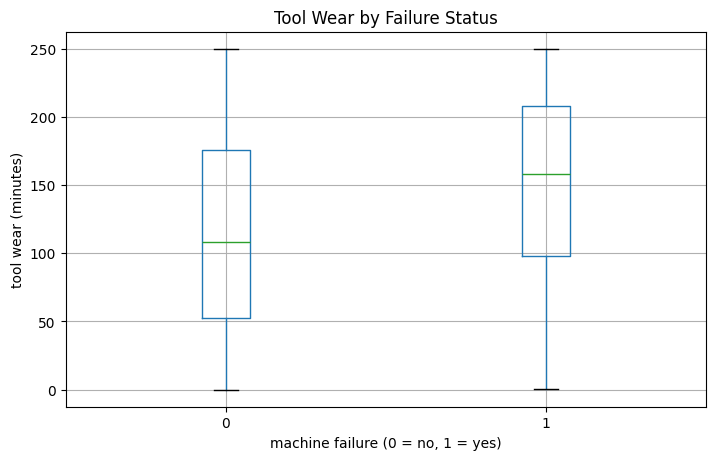

In [4]:
sensor_data.boxplot(column="tool_wear_min", by="machine_failure", figsize=(8, 5))
plt.title("Tool Wear by Failure Status")
plt.suptitle("")
plt.xlabel("machine failure (0 = no, 1 = yes)")
plt.ylabel("tool wear (minutes)")
plt.show()

## Torque vs Failure

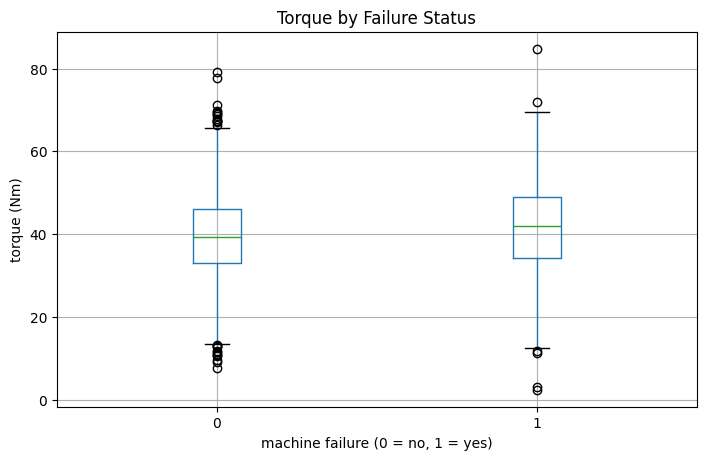

In [5]:
sensor_data.boxplot(column="torque_nm", by="machine_failure", figsize=(8, 5))
plt.title("Torque by Failure Status")
plt.suptitle("")
plt.xlabel("machine failure (0 = no, 1 = yes)")
plt.ylabel("torque (Nm)")
plt.show()

## Correlation Between Sensors

In [6]:
numeric_columns = ["air_temperature_k", "process_temperature_k", "rotational_speed_rpm", "torque_nm", "tool_wear_min", "machine_failure"]
correlation = sensor_data[numeric_columns].corr()
print(correlation["machine_failure"].sort_values(ascending=False))

machine_failure          1.000000
tool_wear_min            0.215306
torque_nm                0.089665
process_temperature_k   -0.006584
air_temperature_k       -0.016234
rotational_speed_rpm    -0.085593
Name: machine_failure, dtype: float64


## What We Learned

- Tool wear and torque both show a clear link to machine failure, matching what the data generator intended.
- Rotational speed has a weaker but still visible relationship.
- These are the features the model in the next notebook will use.